In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import entropy
plt.rcParams['figure.figsize'] = [10, 8]


In [2]:
# Cell 2: Load data
df_ms = pd.read_csv('../data/curated_training_data.affinity.csv.bz2', dtype=str)
df_episcan_a0201 = pd.read_csv('../data/EPISCAN_A0201_sourcedata6.tsv', sep='\t', header=0, dtype=str)
df_episcan_b5701 = pd.read_csv('../data/EPISCAN_B5701_sourcedata6.tsv', sep='\t', header=0, dtype=str)
df_rfdiffusion= pd.read_csv('../data/rdfiffusion_output_peptides.csv.gz',compression='gzip')

In [ ]:
AA = list('ACDEFGHIKLMNPQRSTVWY')

# Standardize alleles in df_ms
df_ms['allele'] = df_ms['allele'].str.replace('HLA-', '').str.replace('*', '').str.replace(':', '')
df_ms['allele'] = df_ms['allele'].str.upper()

# Convert necessary columns to numeric
df_ms['measurement_value'] = pd.to_numeric(df_ms['measurement_value'], errors='coerce')
df_rfdiffusion['plddt'] = pd.to_numeric(df_rfdiffusion['plddt'], errors='coerce')
df_rfdiffusion['length'] = pd.to_numeric(df_rfdiffusion['length'], errors='coerce')

In [119]:
L = 9

# Colors for plots
col_epi = "#3366cc"  # blue for EpiScan / Generated
col_ms = "#cc4444"   # red for MS
col_gen = "#44cc44"  # green for our generated (RFDiffusion), if needed
bar_alpha = 0.85

# Human proteome amino acid frequencies (from PMC article, human-specific)
human_bg = {
    'A': 0.073, 'R': 0.054, 'N': 0.041, 'D': 0.054, 'C': 0.014,
    'E': 0.067, 'Q': 0.039, 'G': 0.067, 'H': 0.023, 'I': 0.059,
    'L': 0.100, 'K': 0.058, 'M': 0.024, 'F': 0.039, 'P': 0.05,
    'S': 0.067, 'T': 0.054, 'W': 0.013, 'Y': 0.033, 'V': 0.06
}

# Function to compute global amino acid frequencies from a list of peptides
def compute_global_freq(peptides, pseudo=0.01):
    all_aa = ''.join(peptides)
    counts = Counter(all_aa)
    total = len(all_aa) + len(AA) * pseudo
    freq = {aa: (counts.get(aa, 0) + pseudo) / total for aa in AA}
    return freq

# Compute PWM (position weight matrix) from list of peptides
def compute_pwm(peptides, length=L, pseudo=1.0):
    """
    Compute PWM as (L, 20) array of probabilities.
    Only use peptides of exact length.
    """
    peptides = [p for p in peptides if len(p) == length]
    counts = np.zeros((length, len(AA)))
    for pep in peptides:
        for i, aa in enumerate(pep):
            if aa in AA:
                counts[i, AA.index(aa)] += 1
    counts += pseudo
    pwm = counts / counts.sum(axis=1, keepdims=True)
    return pwm, len(peptides)  # return PWM and number of peptides used

# Function to convert PWM back to approximate counts (for enrichment calculations)
def pwm_to_counts(pwm, total_n):
    return pwm * (total_n / L)  # approximate per position average

# Function for position-wise Pearson correlation (for Fig 3C in EpiScan / Fig 2 in paper)
def position_correlations(pwm1, pwm2, labels=('Method1', 'Method2')):
    corrs = []
    for pos in range(L):
        freq1 = pwm1[pos]
        freq2 = pwm2[pos]
        r, _ = pearsonr(freq1, freq2)
        corrs.append(r)
    pos = np.arange(1, L+1)
    plt.figure(figsize=(6, 4))
    plt.plot(pos, corrs, marker='o', linestyle='-', color='b')
    plt.xlabel('Sequence Position')
    plt.ylabel('Pearson R')
    plt.title(f'Position-wise correlations of AA preferences\n{labels[0]} vs {labels[1]}')
    plt.ylim(0, 1)
    plt.xticks(pos)
    plt.grid(True, ls='--', alpha=0.5)
    plt.show()
    return corrs

AA_FULL_NAMES = {
    'A': 'Alanine',     'R': 'Arginine',   'N': 'Asparagine',
    'D': 'Aspartic Acid','C': 'Cysteine',   'E': 'Glutamic Acid',
    'Q': 'Glutamine',   'G': 'Glycine',    'H': 'Histidine',
    'I': 'Isoleucine',  'L': 'Leucine',    'K': 'Lysine',
    'M': 'Methionine',  'F': 'Phenylalanine','P': 'Proline',
    'S': 'Serine',      'T': 'Threonine',  'W': 'Tryptophan',
    'Y': 'Tyrosine',    'V': 'Valine'
}

# Function for enrichment plot
def plot_enrichment(allele, pwm_method, pwm_ms, focus_aa=('C', 'P'), label_method='Method', bg_freq=human_bg, save_fig=False, save_fig_name=None):
    # Get number of peptides for scaling
    _, n_method = compute_pwm([], pseudo=0)  # dummy to get structure
    n_method = pwm_method.sum(axis=1).mean() * L  # approx total from probs
    n_ms = pwm_ms.sum(axis=1).mean() * L

    cnt_method = pwm_to_counts(pwm_method, n_method)
    cnt_ms = pwm_to_counts(pwm_ms, n_ms)

    # Global fold enrichment
    glob_fold = (cnt_method.sum(axis=0) / n_method) / (cnt_ms.sum(axis=0) / n_ms)
    aa_sorted = [AA[i] for i in np.argsort(glob_fold)[::-1]]
    glob_sorted = np.sort(glob_fold)[::-1]

    # Per-position fold scaled to background
    def per_pos_fold(cnt, aa, bg):
        idx = AA.index(aa)
        p = cnt[:, idx] / cnt.sum(axis=1)
        return p / bg[aa]

    folds_method = [per_pos_fold(cnt_method, aa, bg_freq) for aa in focus_aa]
    folds_ms = [per_pos_fold(cnt_ms, aa, bg_freq) for aa in focus_aa]

    # Handle NaN/Inf
    for i in range(len(focus_aa)):
        folds_method[i] = np.nan_to_num(folds_method[i], nan=0.0, posinf=0.0, neginf=0.0)
        folds_ms[i] = np.nan_to_num(folds_ms[i], nan=0.0, posinf=0.0, neginf=0.0)
    glob_sorted = np.nan_to_num(glob_sorted, nan=0.0, posinf=0.0, neginf=0.0)

    # Plot
    fig, axs = plt.subplots(1, 1 + len(focus_aa), figsize=(5 + 4*len(focus_aa), 4), constrained_layout=True, sharey=False)

    # Global
    axs[0].bar(aa_sorted, glob_sorted, color='slateblue', alpha=bar_alpha)
    axs[0].axhline(1, ls='--', c='k', lw=1)
    axs[0].set_ylabel(f'Fold enrichment ({label_method} / MS)')
    axs[0].set_title('Global (all positions)')

    pos = np.arange(1, L+1)
    for i, aa in enumerate(focus_aa):
        ax = axs[1 + i]
        m = folds_method[i]
        s = folds_ms[i]
        ax.bar(pos - 0.15, m, width=0.3, label=label_method, color=col_epi, alpha=bar_alpha)
        ax.bar(pos + 0.15, s, width=0.3, label='MS',          color=col_ms,  alpha=bar_alpha)

        # per-axis limit (or just remove these two lines to fully autoscale)
        local_ymax = 1.1 * max(np.max(m), np.max(s), 1.0)
        ax.set_ylim(0, local_ymax)

        ax.axhline(1, ls='--', c='k', lw=1)
        ax.set_xticks(pos)
        ax.set_xlabel('Position')
        full_name = AA_FULL_NAMES.get(aa, aa)
        ax.set_title(f'Enrichment for {full_name} ({aa})')
        if i == 0:
            ax.set_ylabel('Fold enrichment (obs / bg)')
        ax.legend(frameon=False)

    fig.suptitle(f'HLA-{allele} Enrichment (9-mers)', y=1.05)
    
    if save_fig:
        plt.savefig(f'../figures/{save_fig_name}.pdf', dpi=300, bbox_inches='tight')
    else:
        plt.show()



# Function to plot simple KL logo (since no Seq2Logo, use bar plot for each position)
def plot_kl_logo(pwm, bg_freq, title='Logo', kl_scale=True):
    fig, axs = plt.subplots(1, L, figsize=(L*1.5, 5), sharey=False)
    for pos in range(L):
        p = pwm[pos]
        if kl_scale:
            bg = np.array([bg_freq[aa] for aa in AA])
            bg[bg == 0] = 1e-10  # avoid zero division
            kl = p * np.log2(p / bg)
            kl = np.nan_to_num(kl, nan=0.0, posinf=0.0, neginf=0.0)
            kl[kl < 0] = 0  # only positive for enrichment
            heights = kl
        else:
            heights = p
        sorted_idx = np.argsort(heights)[::-1]
        bottom = 0
        for idx in sorted_idx:
            h = heights[idx]
            if h > 0:
                axs[pos].bar(0, h, bottom=bottom, color='gray', alpha=0.8)
                axs[pos].text(0, bottom + h/2, AA[idx], ha='center', va='center')
                bottom += h
        axs[pos].set_title(f'Pos {pos+1}')
        axs[pos].axis('off')
    fig.suptitle(title)
    plt.show()

In [31]:
# Compute backgrounds
decoys_a02 = df_episcan_a0201['Decoys'].dropna().tolist()
decoys_b57 = df_episcan_b5701['Decoys'].dropna().tolist()
episcan_bg = compute_global_freq(decoys_a02 + decoys_b57, pseudo=0.0)  # no pseudo for bg

print('EpiScan BG:', episcan_bg)

# MS peptides for A0201 (binders <500 nM, 9-mer)
ms_peps_a02 = df_ms[(df_ms['allele'] == 'A0201') & (df_ms['measurement_value'].astype(float) < 500) & (df_ms['peptide'].str.len() == 9)]['peptide'].tolist()
pwm_ms_a02, n_ms_a02 = compute_pwm(ms_peps_a02)
print(f'MS A0201: {n_ms_a02} peptides, PWM shape: {pwm_ms_a02.shape}')

# EpiScan high threshold for A0201
episcan_peps_a02 = df_episcan_a0201['Binders - high threshold'].dropna().tolist()
pwm_episcan_a02, n_epi_a02 = compute_pwm(episcan_peps_a02)
print(f'EpiScan A0201: {n_epi_a02} peptides')

# Generated (RFDiffusion) for A0201, high pLDDT >0.8, 9-mer
gen_peps_a02 = df_rfdiffusion[(df_rfdiffusion['hla_allele'] == 'A0201') & (df_rfdiffusion['plddt'].astype(float) > 0.8) & (df_rfdiffusion['length'] == 9)]['epitope'].tolist()
pwm_gen_a02, n_gen_a02 = compute_pwm(gen_peps_a02)
print(f'Generated A0201: {n_gen_a02} peptides')

# Similarly for B5701
ms_peps_b57 = df_ms[(df_ms['allele'] == 'B5701') & (df_ms['measurement_value'].astype(float) < 500) & (df_ms['peptide'].str.len() == 9)]['peptide'].tolist()
pwm_ms_b57, n_ms_b57 = compute_pwm(ms_peps_b57)
print(f'MS B5701: {n_ms_b57} peptides')

episcan_peps_b57 = df_episcan_b5701['Binders - high threshold'].dropna().tolist()
pwm_episcan_b57, n_epi_b57 = compute_pwm(episcan_peps_b57)
print(f'EpiScan B5701: {n_epi_b57} peptides')

gen_peps_b57 = df_rfdiffusion[(df_rfdiffusion['hla_allele'] == 'B5701') & (df_rfdiffusion['plddt'].astype(float) > 0.4) & (df_rfdiffusion['length'] == 9 )]['epitope'].tolist()
pwm_gen_b57, n_gen_b57 = compute_pwm(gen_peps_b57)
print(f'Generated B5701: {n_gen_b57} peptides')

EpiScan BG: {'A': 0.07209114586261807, 'C': 0.02210663376212154, 'D': 0.03748685061997602, 'E': 0.04804690601520029, 'F': 0.05280334388691414, 'G': 0.04747066755402619, 'H': 0.020696195565315146, 'I': 0.06400813208435095, 'K': 0.04216252650748037, 'L': 0.13547328737737893, 'M': 0.027951824965267234, 'N': 0.028551917177051737, 'P': 0.04277590866603352, 'Q': 0.03524323499113492, 'R': 0.04279874011304633, 'S': 0.07780139299088207, 'T': 0.05689085443793918, 'V': 0.08344110117091247, 'W': 0.027673076850991414, 'Y': 0.034526259401359456}
MS A0201: 7144 peptides, PWM shape: (9, 20)
EpiScan A0201: 12676 peptides
Generated A0201: 247 peptides
MS B5701: 402 peptides
EpiScan B5701: 7381 peptides
Generated B5701: 78 peptides


In [10]:
no_binding_pocket = pd.read_csv('../data/negative_ctrl_library.csv')

gen_nba_peps_all = no_binding_pocket[(no_binding_pocket['plddt'].astype(float) > 0.8) & (no_binding_pocket['length'] == 9 )]['epitope'].tolist()
pwm_nba_gen_all, n_nba_gen_all = compute_pwm(gen_nba_peps_all)
print(f'Generated all01: {n_nba_gen_all} peptides')

def normalize_rows(mat, eps=1e-6):
    mat = np.asarray(mat, dtype=float)
    mat = mat + eps  # avoid division by zero
    return mat / mat.sum(axis=1, keepdims=True)

# P_signal = normalize_rows(pwm_gen_all)
# P_noise  = normalize_rows(pwm_nba_gen_all)


# log_odds_pwm = np.log2(P_signal / P_noise)


Generated all01: 301 peptides


A0201 Generated vs MS correlations:


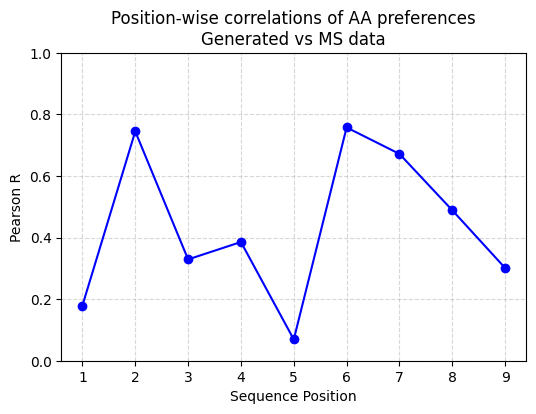

A0201 EpiScan vs MS correlations:


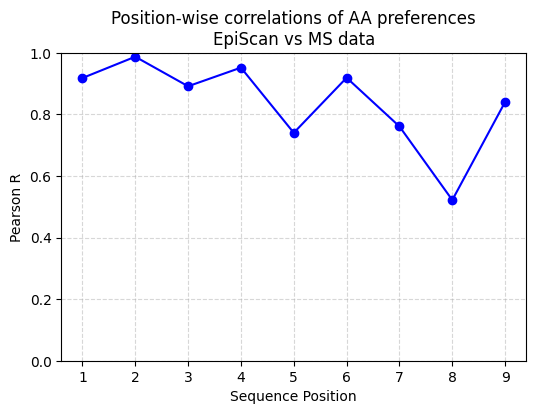

B5701 Generated vs MS correlations (low data):


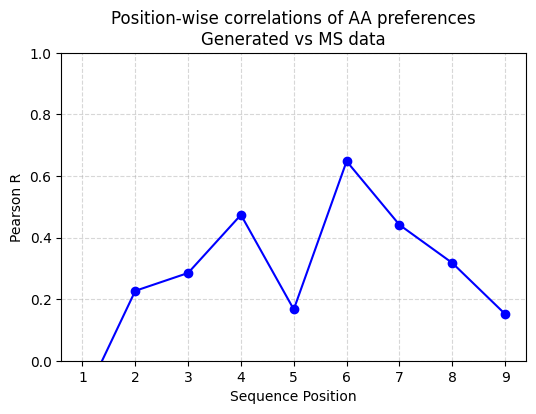

B5701 EpiScan vs MS correlations:


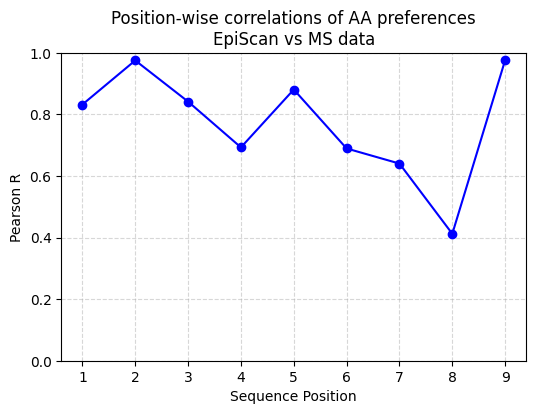

EpiScan B5701 high+low: 11647 peptides
B5701 EpiScan high+low vs MS correlations:


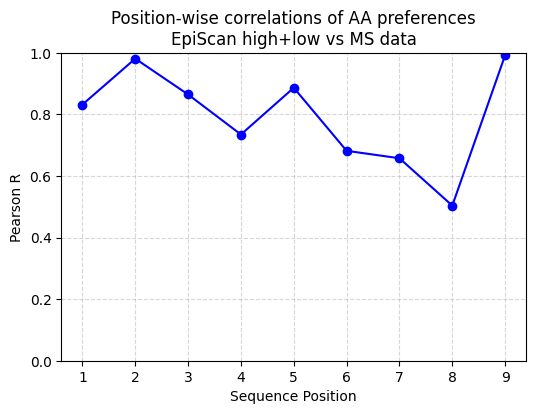

All Generated B5701 9-mer: 516 peptides
B5701 All Generated vs MS correlations:


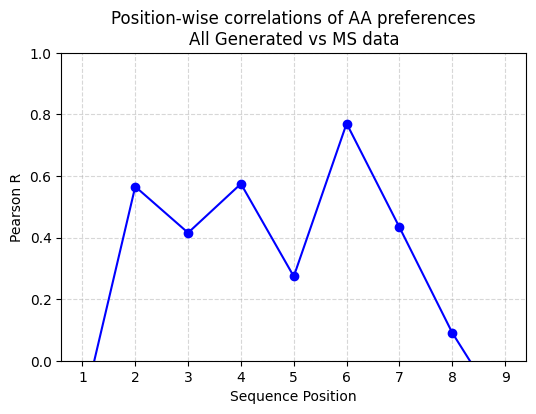

[-0.16374775717778767,
 0.5653629113352237,
 0.41533967901883406,
 0.5744615739478843,
 0.2737147748413248,
 0.7701636333163743,
 0.43319245510072013,
 0.09050295229776685,
 -0.1826203608925052]

In [146]:
# Position-wise correlations for A0201
print('A0201 Generated vs MS correlations:')
position_correlations(pwm_gen_a02, pwm_ms_a02, labels=('Generated', 'MS data'))

print('A0201 EpiScan vs MS correlations:')
position_correlations(pwm_episcan_a02, pwm_ms_a02, labels=('EpiScan', 'MS data'))

# For B5701, note low number, but plot anyway
print('B5701 Generated vs MS correlations (low data):')
position_correlations(pwm_gen_b57, pwm_ms_b57, labels=('Generated', 'MS data'))

print('B5701 EpiScan vs MS correlations:')
position_correlations(pwm_episcan_b57, pwm_ms_b57, labels=('EpiScan', 'MS data'))

# To include low threshold for EpiScan B5701
low_peps_b57 = df_episcan_b5701['Binders - low threshold'].dropna().tolist()
all_epi_peps_b57 = list(set(episcan_peps_b57 + low_peps_b57))  # unique combined
pwm_all_epi_b57, n_all_epi_b57 = compute_pwm(all_epi_peps_b57)
print(f'EpiScan B5701 high+low: {n_all_epi_b57} peptides')

print('B5701 EpiScan high+low vs MS correlations:')
position_correlations(pwm_all_epi_b57, pwm_ms_b57, labels=('EpiScan high+low', 'MS data'))

# For generated B5701, to get more, relax pLDDT to >0.0 (all)
gen_peps_b57_all = df_rfdiffusion[(df_rfdiffusion['hla_allele'] == 'B5701') & (df_rfdiffusion['length'] == 9)]['epitope'].tolist()
pwm_gen_b57_all, n_gen_b57_all = compute_pwm(gen_peps_b57_all)
print(f'All Generated B5701 9-mer: {n_gen_b57_all} peptides')

print('B5701 All Generated vs MS correlations:')
position_correlations(pwm_gen_b57_all, pwm_ms_b57, labels=('All Generated', 'MS data'))

In [147]:
# Qualitative MS for A0201
ms_qual_a02 = df_ms[(df_ms['allele'] == 'A0201') & (df_ms['measurement_type'] == 'qualitative') & (df_ms['peptide'].str.len() == 9)]['peptide'].tolist()
pwm_ms_qual_a02, n_ms_qual_a02 = compute_pwm(ms_qual_a02)
print(f'Qualitative MS A0201: {n_ms_qual_a02} peptides')

# Similarly for B5701
ms_qual_b57 = df_ms[(df_ms['allele'] == 'B5701') & (df_ms['measurement_type'] == 'qualitative') & (df_ms['peptide'].str.len() == 9)]['peptide'].tolist()
pwm_ms_qual_b57, n_ms_qual_b57 = compute_pwm(ms_qual_b57)
print(f'Qualitative MS B5701: {n_ms_qual_b57} peptides')

Qualitative MS A0201: 6091 peptides
Qualitative MS B5701: 182 peptides


In [12]:
# Combine high + low for A0201 EpiScan
low_peps_a02 = df_episcan_a0201['Binders - low threshold'].dropna().tolist()
all_epi_peps_a02 = list(set(episcan_peps_a02 + low_peps_a02))  # unique combined
pwm_all_epi_a02, n_all_epi_a02 = compute_pwm(all_epi_peps_a02)
print(f'EpiScan A0201 high+low: {n_all_epi_a02} peptides')

# Update human_bg with UniProt/Swiss-Prot frequencies (decimal)
human_bg = human_bg = {
    'A': 0.073, 'R': 0.054, 'N': 0.041, 'D': 0.054, 'C': 0.014,
    'E': 0.067, 'Q': 0.039, 'G': 0.067, 'H': 0.023, 'I': 0.059,
    'L': 0.100, 'K': 0.058, 'M': 0.024, 'F': 0.039, 'P': 0.05,
    'S': 0.067, 'T': 0.054, 'W': 0.013, 'Y': 0.033, 'V': 0.06
}

EpiScan A0201 high+low: 30093 peptides


In [13]:
# Cell: Filter for Sarkizova MS if available, else qualitative
sark_source = df_ms[df_ms['measurement_source'].str.contains('Sarkizova', na=False)]
if not sark_source.empty:
    ms_peps_a02 = sark_source[(sark_source['allele'] == 'A0201') & (sark_source['peptide'].str.len() == 9)]['peptide'].tolist()
    ms_peps_b57 = sark_source[(sark_source['allele'] == 'B5701') & (sark_source['peptide'].str.len() == 9)]['peptide'].tolist()
    print('Using Sarkizova MS data')
else:
    ms_peps_a02 = df_ms[(df_ms['allele'] == 'A0201') & (df_ms['measurement_type'] == 'qualitative') & (df_ms['peptide'].str.len() == 9)]['peptide'].tolist()
    ms_peps_b57 = df_ms[(df_ms['allele'] == 'B5701') & (df_ms['measurement_type'] == 'qualitative') & (df_ms['peptide'].str.len() == 9)]['peptide'].tolist()
    print('Sarkizova not found; using qualitative MS')

pwm_ms_a02, n_ms_a02 = compute_pwm(ms_peps_a02)
pwm_ms_b57, n_ms_b57 = compute_pwm(ms_peps_b57)
print(f'MS A0201: {n_ms_a02}, B5701: {n_ms_b57}')

Sarkizova not found; using qualitative MS
MS A0201: 6091, B5701: 182


In [ ]:
# Cell: Filter for Sarkizova MS if available, else qualitative
sark_source = df_ms[df_ms['measurement_source'].str.contains('Sarkizova', na=False)]

if not sark_source.empty:
    ms_peps_a02 = sark_source[(sark_source['allele'] == 'A0201') & (sark_source['peptide'].str.len() == 9)]['peptide'].tolist()
    ms_peps_b57 = sark_source[(sark_source['allele'] == 'B5701') & (sark_source['peptide'].str.len() == 9)]['peptide'].tolist()
    print('Using Sarkizova MS data')
else:
    ms_peps_a02 = df_ms[(df_ms['allele'] == 'A0201') & (df_ms['measurement_type'] == 'qualitative') & (df_ms['peptide'].str.len() == 9)]['peptide'].tolist()
    ms_peps_b57 = df_ms[(df_ms['allele'] == 'B5701') & (df_ms['measurement_type'] == 'qualitative') & (df_ms['peptide'].str.len() == 9)]['peptide'].tolist()
    print('Sarkizova not found; using qualitative MS')

pwm_ms_a02, n_ms_a02 = compute_pwm(ms_peps_a02)
pwm_ms_b57, n_ms_b57 = compute_pwm(ms_peps_b57)
print(f'MS A0201: {n_ms_a02}, B5701: {n_ms_b57}')

Sarkizova not found; using qualitative MS
MS A0201: 6091, B5701: 182


In [52]:
# Cell: Load Sarkizova Suppl Table 1
df_sark = pd.read_csv('../data/Sarkizova_supp1.csv', sep = '\t')#, sheet_name='e. Filtered peptide list')

# Extract 9-mer peptides for A*02:01 and B*57:01 (note allele format in data)
ms_peps_a02 = df_sark[(df_sark['Allele'] == 'A0201') & (df_sark['Length'] == 9)]['Peptide'].tolist()
ms_peps_b57 = df_sark[(df_sark['Allele'] == 'B5701') & (df_sark['Length'] == 9)]['Peptide'].tolist()

pwm_ms_a02, n_ms_a02 = compute_pwm(ms_peps_a02)
pwm_ms_b57, n_ms_b57 = compute_pwm(ms_peps_b57)
print(f'Sarkizova MS A0201: {n_ms_a02} peptides, B5701: {n_ms_b57} peptides')

Sarkizova MS A0201: 2075 peptides, B5701: 501 peptides


/tmp/ipykernel_2908451/1124852617.py:38: RuntimeWarning: invalid value encountered in divide
  pwm = counts / counts.sum(axis=1, keepdims=True)


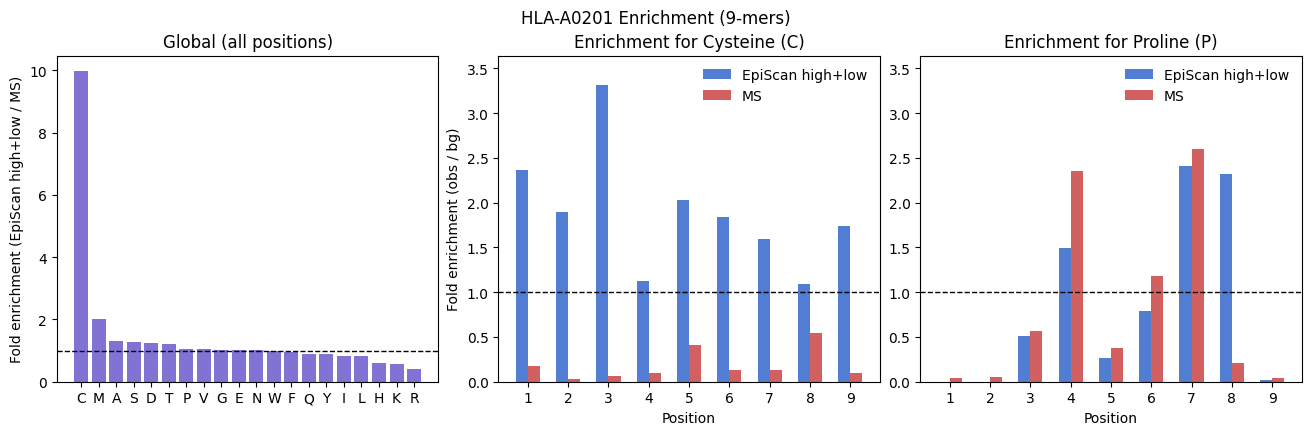

In [75]:
# Cell: Replication of Fig 3E for A*02:01 (EpiScan high+low vs Sarkizova MS, focus C/P)
plot_enrichment('A0201', pwm_method=pwm_all_epi_a02,
                    pwm_ms=pwm_ms_a02,
                    focus_aa=('C', 'P'),
                    label_method='EpiScan high+low',
                    bg_freq=human_bg,
                    save_fig=True,
                    save_fig_name='sarkizova_epi_a0201_enrichment_C_P')

/tmp/ipykernel_2908451/1124852617.py:38: RuntimeWarning: invalid value encountered in divide
  pwm = counts / counts.sum(axis=1, keepdims=True)


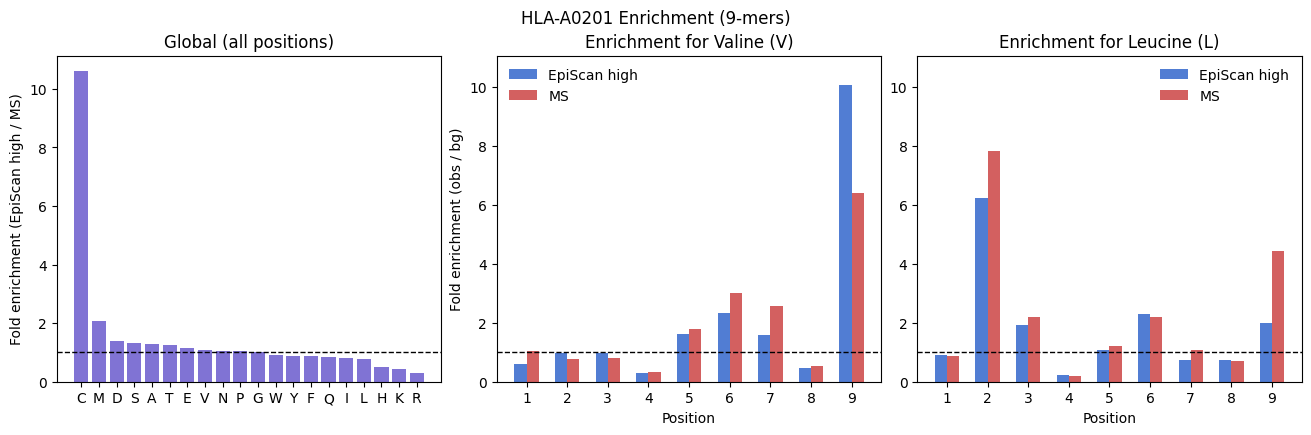

In [76]:
    # Cell: Replication of Fig 3E for A*02:01 (EpiScan high only vs Sarkizova MS, focus C/P)
plot_enrichment('A0201', pwm_method=pwm_episcan_a02,
    pwm_ms=pwm_ms_a02,
    focus_aa=('V', 'L'),
    label_method='EpiScan high',
    bg_freq=human_bg,
    save_fig=True,
    save_fig_name='sarkizova_epi_a0201_enrichment_V_L')

/tmp/ipykernel_2908451/1124852617.py:38: RuntimeWarning: invalid value encountered in divide
  pwm = counts / counts.sum(axis=1, keepdims=True)


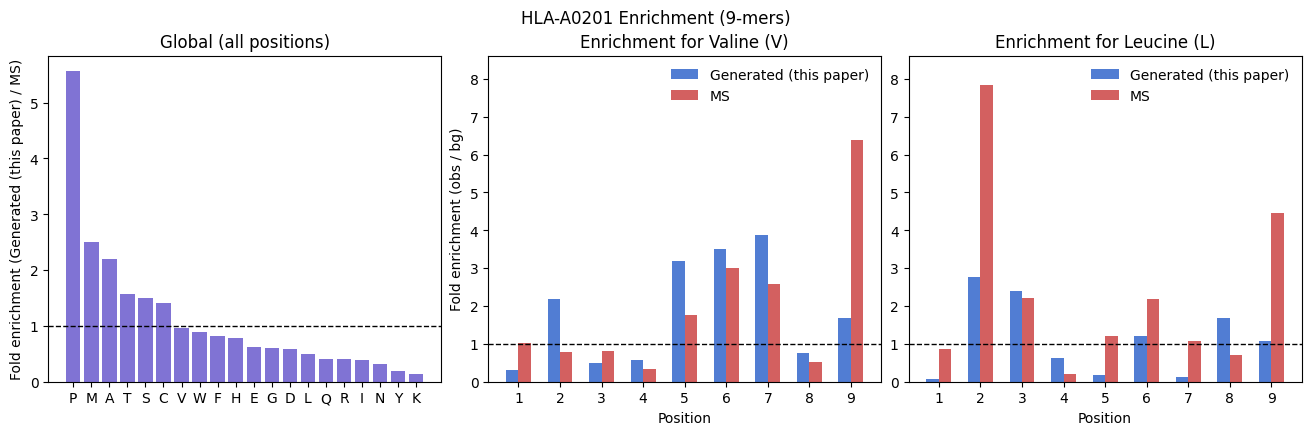

In [77]:
# Cell: This paper Generated vs Sarkizova MS for A*02:01 (focus C/P)
plot_enrichment('A0201',
    pwm_method=pwm_gen_a02,
    pwm_ms=pwm_ms_a02,
    focus_aa=('V', 'L'),
    label_method='Generated (this paper)',
    bg_freq=human_bg,
    save_fig=True,
    save_fig_name='sarkizova_gen_a0201_enrichment_V_L')

/tmp/ipykernel_2908451/1309216388.py:38: RuntimeWarning: invalid value encountered in divide
  pwm = counts / counts.sum(axis=1, keepdims=True)


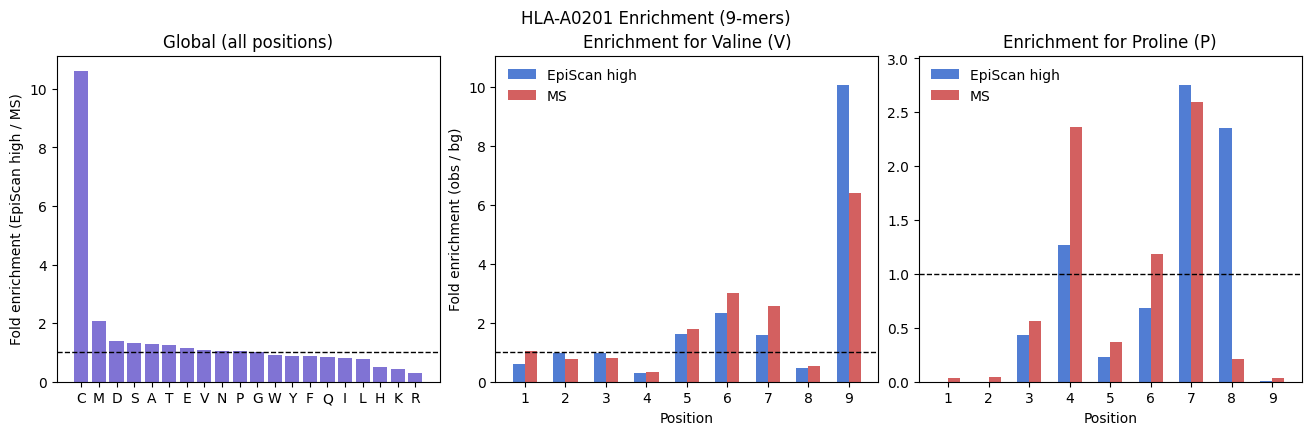

In [152]:
    # Cell: Replication of Fig 3E for A*02:01 (EpiScan high only vs Sarkizova MS, focus C/P)
plot_enrichment('A0201', pwm_method=pwm_episcan_a02,
    pwm_ms=pwm_ms_a02,
    focus_aa=('V', 'P'),
    label_method='EpiScan high',
    bg_freq=human_bg,
    save_fig=True,
    save_fig_name='sarkizova_epi_a0201_enrichment_V_L')

/tmp/ipykernel_2908451/1309216388.py:38: RuntimeWarning: invalid value encountered in divide
  pwm = counts / counts.sum(axis=1, keepdims=True)


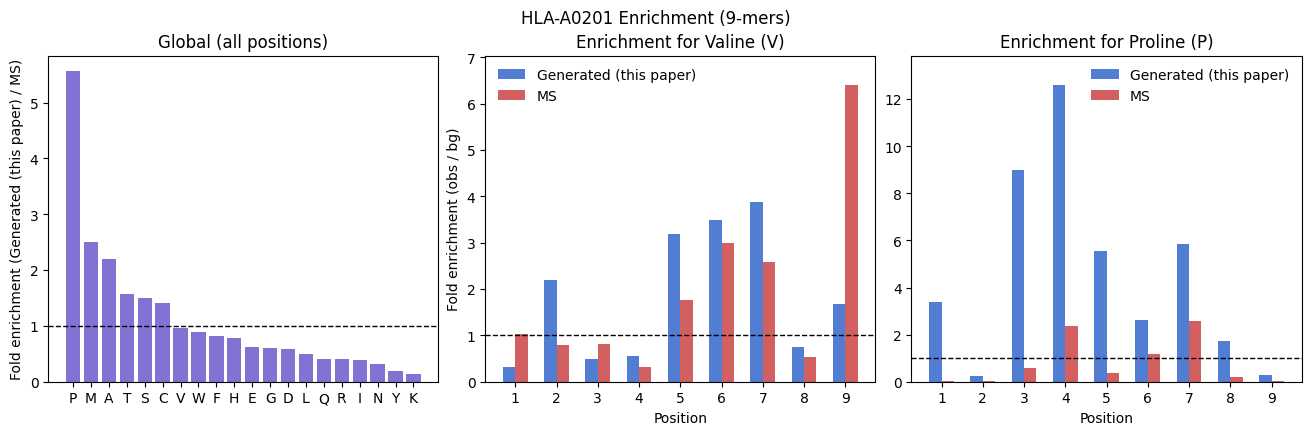

In [151]:
# Cell: This paper Generated vs Sarkizova MS for A*02:01 (focus C/P)
plot_enrichment('A0201',
    pwm_method=pwm_gen_a02,
    pwm_ms=pwm_ms_a02,
    focus_aa=('V', 'P'),
    label_method='Generated (this paper)',
    bg_freq=human_bg,
    save_fig=True,
    save_fig_name='sarkizova_gen_a0201_enrichment_V_L')

/tmp/ipykernel_2908451/1124852617.py:38: RuntimeWarning: invalid value encountered in divide
  pwm = counts / counts.sum(axis=1, keepdims=True)


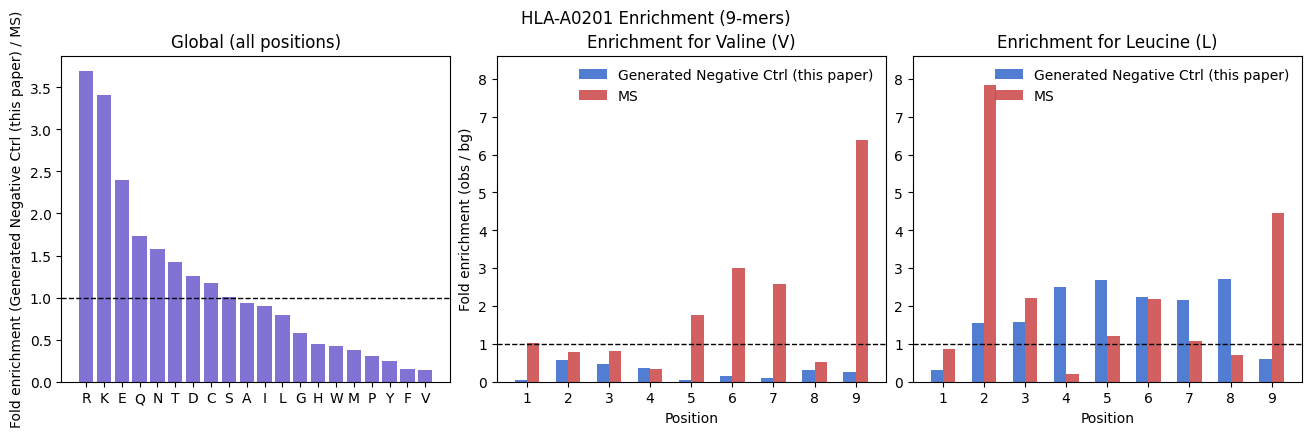

In [78]:
    # Cell: This paper Generated vs Sarkizova MS for A*02:01 (focus C/P)a
plot_enrichment('A0201',
    pwm_method=pwm_nba_gen_all,
    pwm_ms=pwm_ms_a02,
    focus_aa=('V', 'L'),
    label_method='Generated Negative Ctrl (this paper)',
    bg_freq=human_bg)

/tmp/ipykernel_2908451/1309216388.py:38: RuntimeWarning: invalid value encountered in divide
  pwm = counts / counts.sum(axis=1, keepdims=True)


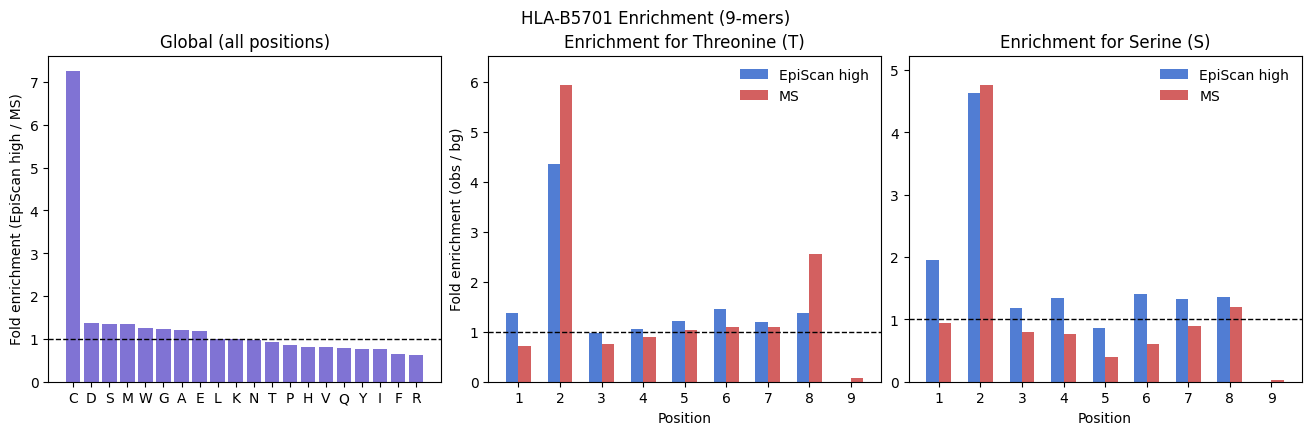

In [120]:
# Cell: Replication of Fig 3E for B*57:01 (EpiScan high only vs Sarkizova MS, focus C/P)
plot_enrichment('B5701',
    pwm_method=pwm_episcan_b57,
    pwm_ms=pwm_ms_b57,
    focus_aa=('T', 'S'),
    label_method='EpiScan high',
    bg_freq=human_bg,
    save_fig=True,
    save_fig_name='sarkizova_epi_b5701_enrichment_T_S')

/tmp/ipykernel_2908451/1124852617.py:38: RuntimeWarning: invalid value encountered in divide
  pwm = counts / counts.sum(axis=1, keepdims=True)


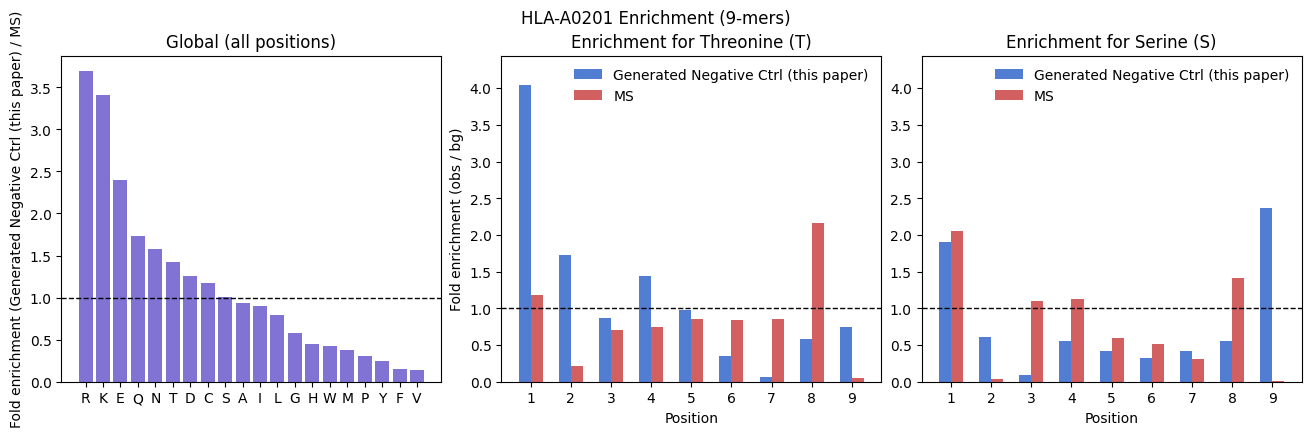

In [80]:
# Cell: This paper Generated vs Sarkizova MS for A*02:01 (focus C/P)a
plot_enrichment('A0201',
    pwm_method=pwm_nba_gen_all,
    pwm_ms=pwm_ms_a02,
    focus_aa=('T', 'S'),
    label_method='Generated Negative Ctrl (this paper)',
    bg_freq=human_bg,
    save_fig=True,
    save_fig_name='sarkizova_gen_nba_a0201_enrichment_T_S')

/tmp/ipykernel_2908451/1309216388.py:38: RuntimeWarning: invalid value encountered in divide
  pwm = counts / counts.sum(axis=1, keepdims=True)
/tmp/ipykernel_2908451/1309216388.py:38: RuntimeWarning: invalid value encountered in divide
  pwm = counts / counts.sum(axis=1, keepdims=True)


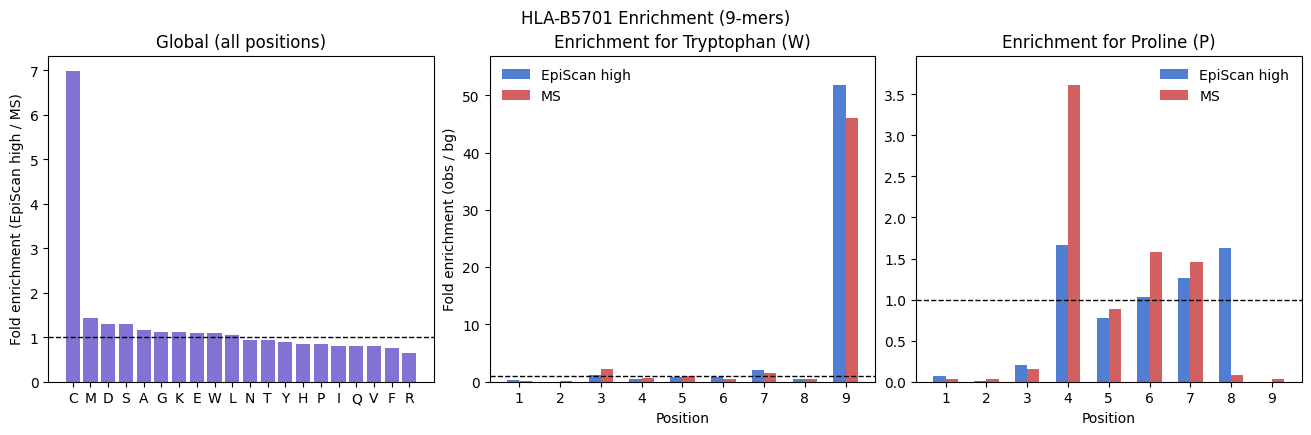

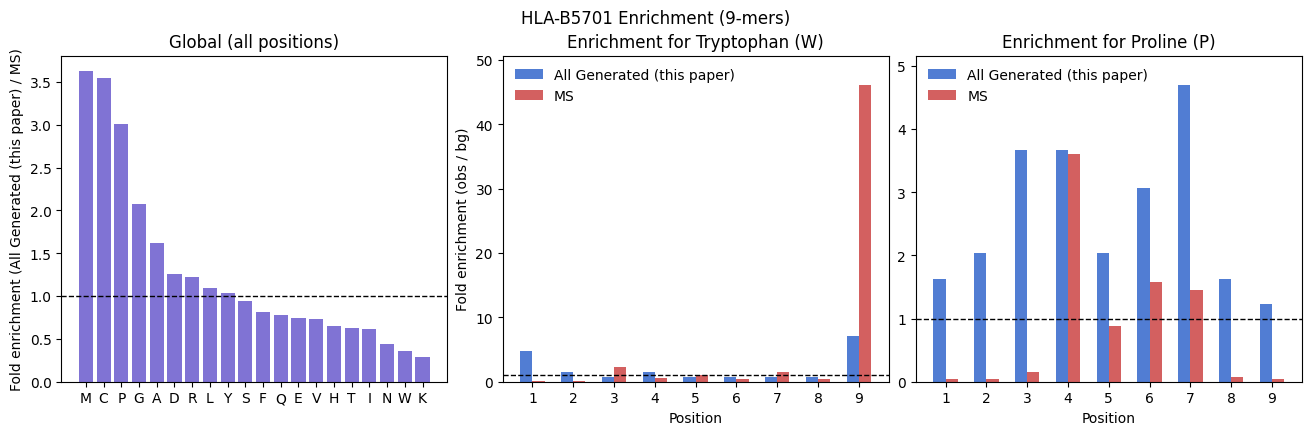

In [149]:
residue = 'W'
residue_2 = 'P'

# Cell: Replication of Fig 3E for B*57:01 (EpiScan high only vs Sarkizova MS, focus C/P)
plot_enrichment('B5701',
    pwm_method=pwm_all_epi_b57,
    pwm_ms=pwm_ms_b57,
    focus_aa=(residue, residue_2),
    label_method='EpiScan high',
    bg_freq=human_bg,
    save_fig=True,
    save_fig_name='sarkizova_epi_b5701_enrichment_A_L')

# Cell: This paper All Generated vs Sarkizova MS for B*57:01 (focus C/P)
plot_enrichment('B5701',
 pwm_method=pwm_gen_b57,
 pwm_ms=pwm_ms_b57,
 focus_aa=(residue,residue_2),
 label_method='All Generated (this paper)',
 bg_freq=human_bg,
 save_fig=True,
 save_fig_name='sarkizova_gen_b5701_enrichment_T_S')